In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


FF++ clean test set

In [2]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/ffpp_cropped_faces/test /content/

!mv /content/test /content/ffpp_test

CelebV2 clean set


In [3]:
!cp -r /content/drive/MyDrive/DL_Project/datasets/celebv2_cropped_faces /content/

Compressed Dataset

In [4]:
!cp /content/drive/MyDrive/DL_Project/datasets/compressed_ffpp_celebv2.zip /content/

In [5]:
!unzip -q /content/compressed_ffpp_celebv2.zip -d /content/

Dependencies and Imports...

In [6]:
!pip install -q timm torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.2 MB/s eta 0:00:00


In [25]:
import timm

import os
import random
from tqdm.auto import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import cv2
import scipy.fftpack as fftpack

import torch.nn.functional as F

In [26]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='torch.utils.data.dataloader')

Rrproducibility...

In [27]:
seed = 42

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Datasets...

In [29]:
DATASETS = {
    # ff++..
    'ffpp_clean':
        '/content/ffpp_test',

    'ffpp_q90':
        '/content/compressed_ffpp_celebv2/ffpp/q90',

    'ffpp_q70':
        '/content/compressed_ffpp_celebv2/ffpp/q70',

    'ffpp_q50':
        '/content/compressed_ffpp_celebv2/ffpp/q50',

    'ffpp_q30':
        '/content/compressed_ffpp_celebv2/ffpp/q30',

    'ffpp_q10':
        '/content/compressed_ffpp_celebv2/ffpp/q10',

    # celebv2...
    'celebv2_clean':
        '/content/celebv2_cropped_faces',

    'celebv2_q90':
        '/content/compressed_ffpp_celebv2/celebv2/q90',

    'celebv2_q70':
        '/content/compressed_ffpp_celebv2/celebv2/q70',

    'celebv2_q50':
        '/content/compressed_ffpp_celebv2/celebv2/q50',

    'celebv2_q30':
        '/content/compressed_ffpp_celebv2/celebv2/q30',

    'celebv2_q10':
        '/content/compressed_ffpp_celebv2/celebv2/q10',
}

In [30]:
for name, path in DATASETS.items():

    real_count = len(os.listdir(os.path.join(path, 'real')))

    fake_count = len(os.listdir(os.path.join(path, 'fake')))

    print(f'{name:15s} | '
    f'real={real_count:4d} | '
    f'fake={fake_count:4d} | '
    f'total={real_count+fake_count:4d}')

ffpp_clean      | real=1250 | fake=1138 | total=2388
ffpp_q90        | real=1250 | fake=1138 | total=2388
ffpp_q70        | real=1250 | fake=1138 | total=2388
ffpp_q50        | real=1250 | fake=1138 | total=2388
ffpp_q30        | real=1250 | fake=1138 | total=2388
ffpp_q10        | real=1250 | fake=1138 | total=2388
celebv2_clean   | real=2999 | fake=2991 | total=5990
celebv2_q90     | real=2999 | fake=2991 | total=5990
celebv2_q70     | real=2999 | fake=2991 | total=5990
celebv2_q50     | real=2999 | fake=2991 | total=5990
celebv2_q30     | real=2999 | fake=2991 | total=5990
celebv2_q10     | real=2999 | fake=2991 | total=5990


DCT Feature Generation...

In [31]:
def compute_dct_map(pil_image, image_size=299):

    image = np.array(pil_image.convert('L'))

    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)

    image = image.astype(np.float32)

    dct_image = fftpack.dct(fftpack.dct(image.T, norm='ortho').T, norm='ortho')

    dct_image = np.log1p(np.abs(dct_image))

    p1 = np.percentile(dct_image, 1)
    p99 = np.percentile(dct_image, 99)

    dct_image = np.clip(dct_image, p1, p99)

    dct_image = (dct_image - dct_image.min()) / (
        dct_image.max()
        - dct_image.min()
        + 1e-8
    )

    return torch.tensor(dct_image, dtype=torch.float32).unsqueeze(0)

Dataset Class...

In [32]:
class DCTDeepfakeDataset(Dataset):

    def __init__(self, root_dir, rgb_transform=None, image_size=299):

        self.rgb_transform = rgb_transform
        self.image_size = image_size

        self.samples = []

        real_dir = os.path.join(root_dir, 'real')
        fake_dir = os.path.join(root_dir, 'fake')

        for img in sorted(os.listdir(real_dir)):

            self.samples.append((os.path.join(real_dir, img), 0))

        for img in sorted(os.listdir(fake_dir)):

            self.samples.append((os.path.join(fake_dir, img), 1))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')

        rgb_image = image

        if self.rgb_transform:
            rgb_image = self.rgb_transform(rgb_image)

        dct_image = compute_dct_map(image, self.image_size)

        return (rgb_image, dct_image, torch.tensor(label, dtype=torch.float32))

Frequency Branch...

In [33]:
class FrequencyBranch(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(128, 256)

    def forward(self, x):

        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        x = F.normalize(x, p=2, dim=1)

        return x

DCT-Aware Xception...

In [34]:
class DCTAwareXception(nn.Module):

    def __init__(self):

        super().__init__()

        # rgp branch..

        self.rgb_backbone = timm.create_model('xception65', pretrained=True, num_classes=0)

        rgb_feature_dim = self.rgb_backbone.num_features

        # dct branch..

        self.freq_branch = FrequencyBranch()

        # fusion,..

        self.fusion = nn.Sequential(

            nn.Linear(rgb_feature_dim + 256, 512),

            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(512, 1)
        )

    def forward(self, rgb, dct):

        rgb_features = self.rgb_backbone(rgb)
        rgb_features = F.normalize(rgb_features, p=2, dim=1)
        dct_features = self.freq_branch(dct)

        fused = torch.cat([rgb_features, dct_features], dim=1)
        logits = self.fusion(fused)

        return logits.squeeze(1)

Model Loading...

In [35]:
dct_model = DCTAwareXception()

checkpoint_path = ('/content/drive/MyDrive/DL_Project/checkpoints/best_cat_dct_xception.pth')
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

dct_model.load_state_dict(checkpoint['model_state_dict'])
dct_model = dct_model.to(device)
dct_model.eval()

print(
    f'\nDCT_CAT_Xception loaded '
    f'(best auc = '
    f'{checkpoint['best_auc']:.4f})'
)


DCT_CAT_Xception loaded (best auc = 0.9673)


Evaluation Function...

In [36]:
@torch.no_grad()

def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_probs = []
    all_preds = []

    for rgb_images, dct_images, labels in tqdm(loader, leave=False):

        rgb_images = rgb_images.to(device)
        dct_images = dct_images.to(device)
        labels = labels.to(device)
        outputs = model(rgb_images, dct_images)
        labels = labels.float().view_as(outputs)

        loss = criterion(outputs, labels)

        running_loss += (loss.item() * rgb_images.size(0))

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = (running_loss / len(loader.dataset))
    auc = roc_auc_score(all_labels, all_probs)

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return {
        'loss': epoch_loss,
        'auc': auc,

        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'labels': np.array(all_labels),
        'probs': np.array(all_probs),
        'preds': np.array(all_preds)
    }

Transforms and Loss Function...

In [37]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

xception_transform = transforms.Compose([transforms.Resize((299,299)), transforms.ToTensor(),
                                         transforms.Normalize(imagenet_mean, imagenet_std)])

In [38]:
criterion = nn.BCEWithLogitsLoss()

In [39]:
def evaluate_all_datasets_dct():

    results = []
    stored_metrics = {}

    for dataset_name, dataset_path in DATASETS.items():

        print(f'\nDCT_CAT_XCEPTION | {dataset_name}')

        dataset = DCTDeepfakeDataset(dataset_path, rgb_transform=xception_transform, image_size=299)
        loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)
        metrics = evaluate(dct_model, loader, criterion)

        stored_metrics[dataset_name] = metrics

        dataset_type = (
            'FF++'
            if 'ffpp' in dataset_name
            else 'CelebV2'
        )

        quality = dataset_name.split('_')[-1]

        results.append({
            'Model':
                'DCT_CAT_Xception',

            'Dataset':
                dataset_type,

            'Quality':
                quality,

            'AUC':
                metrics['auc'],

            'Accuracy':
                metrics['accuracy'],

            'Precision':
                metrics['precision'],

            'Recall':
                metrics['recall'],

            'F1':
                metrics['f1']
        })

        print(
            f'AUC={metrics['auc']:.4f} | '
            f'ACC={metrics['accuracy']:.4f} | '
            f'F1={metrics['f1']:.4f}'
        )

    results_df = pd.DataFrame(results)

    return (results_df,stored_metrics)

Evaluations...

In [40]:
OUTPUT_DIR = ('/content/drive/MyDrive/DL_Project/results/dct_cat_xception_compression_results')
os.makedirs(OUTPUT_DIR,exist_ok=True)

dct_results_df, dct_metrics = (evaluate_all_datasets_dct())


DCT_CAT_XCEPTION | ffpp_clean


  0%|          | 0/75 [00:00<?, ?it/s]

AUC=0.9388 | ACC=0.8769 | F1=0.8720

DCT_CAT_XCEPTION | ffpp_q90


  0%|          | 0/75 [00:00<?, ?it/s]

AUC=0.9340 | ACC=0.8685 | F1=0.8644

DCT_CAT_XCEPTION | ffpp_q70


...

AUC=0.7741 | ACC=0.6529 | F1=0.7311

DCT_CAT_XCEPTION | celebv2_q30


  0%|          | 0/188 [00:00<?, ?it/s]

AUC=0.7562 | ACC=0.6469 | F1=0.7226

DCT_CAT_XCEPTION | celebv2_q10


  0%|          | 0/188 [00:00<?, ?it/s]

AUC=0.6888 | ACC=0.6242 | F1=0.6807


In [41]:
dct_csv = os.path.join(OUTPUT_DIR, 'dct_cat_xception_compression_results.csv')
dct_results_df.to_csv(dct_csv, index=False)

print(f'\nsaved: {dct_csv}')

display(dct_results_df)


saved: /content/drive/MyDrive/DL_Project/results/dct_cat_xception_compression_results/dct_cat_xception_compression_results.csv


,Model,Dataset,Quality,AUC,Accuracy,Precision,Recall,F1
0,DCT_CAT_Xception,FF++,clean,0.938794,0.876884,0.864421,0.879613,0.871951
1,DCT_CAT_Xception,FF++,q90,0.933989,0.868509,0.849745,0.879613,0.864421
2,DCT_CAT_Xception,FF++,q70,0.930857,0.858459,0.837838,0.871705,0.854436
3,DCT_CAT_Xception,FF++,q50,0.914928,0.842546,0.818562,0.860281,0.838903
4,DCT_CAT_Xception,FF++,q30,0.887768,0.815327,0.799142,0.818102,0.808511
5,DCT_CAT_Xception,FF++,q10,0.791187,0.712312,0.741693,0.608084,0.668276
6,DCT_CAT_Xception,CelebV2,clean,0.792147,0.634391,0.580180,0.968907,0.725770
7,DCT_CAT_Xception,CelebV2,q90,0.781000,0.628047,0.575679,0.970244,0.722610
8,DCT_CAT_Xception,CelebV2,q70,0.785238,0.652588,0.595029,0.952524,0.732485
9,DCT_CAT_Xception,CelebV2,q50,0.774137,0.652922,0.596203,0.944835,0.731083


In [42]:
QUALITY_ORDER = [
    'clean',
    'q90',
    'q70',
    'q50',
    'q30',
    'q10'
]

def plot_single_curve(df, model_name, dataset_name, save_name):

    subset = df[(df['Model'] == model_name) & (df['Dataset'] == dataset_name)].copy()
    subset['Quality'] = pd.Categorical(subset['Quality'], categories=QUALITY_ORDER, ordered=True)
    subset = subset.sort_values('Quality')

    plt.figure(figsize=(8,5))

    plt.plot(subset['Quality'], subset['AUC'], marker='o')
    plt.title(f'{model_name} - {dataset_name}')
    plt.xlabel('JPEG Quality')
    plt.ylabel('AUC')

    plt.grid(True)

    save_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    print(f'\nsaved: {save_path}')

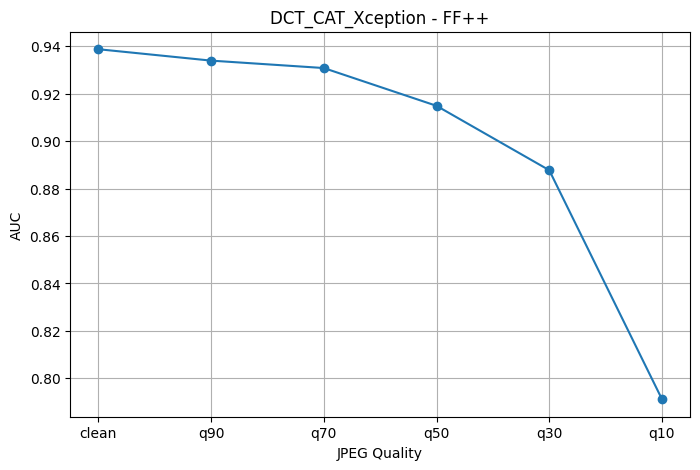


saved: /content/drive/MyDrive/DL_Project/results/dct_cat_xception_compression_results/dct_cat_xception_ffpp_compression_auc.pdf


In [43]:
plot_single_curve(
    dct_results_df,
    'DCT_CAT_Xception',
    'FF++',
    'dct_cat_xception_ffpp_compression_auc.pdf'
)

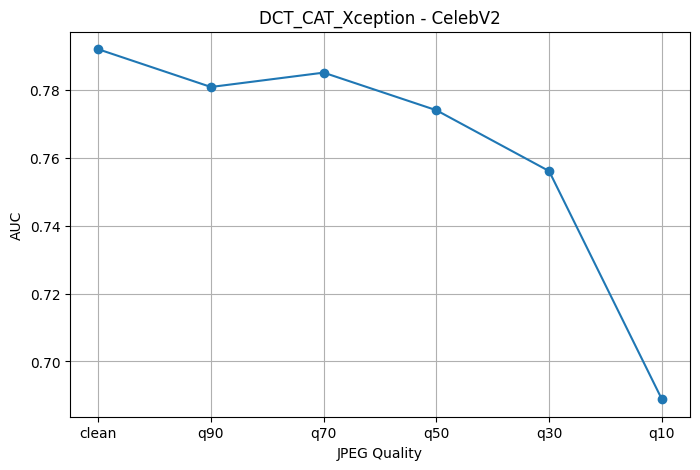


saved: /content/drive/MyDrive/DL_Project/results/dct_cat_xception_compression_results/dct_cat_xception_celebv2_compression_auc.pdf


In [44]:
plot_single_curve(
    dct_results_df,
    'DCT_CAT_Xception',
    'CelebV2',
    'dct_cat_xception_celebv2_compression_auc.pdf'
)

In [45]:
def save_confusion_matrix(metrics, dataset_name, model_name):

    labels = metrics['labels']
    preds = metrics['preds']

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f'{model_name} - {dataset_name}')

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    save_path = os.path.join(OUTPUT_DIR, f'{model_name.lower()}_{dataset_name}_confusion_matrix.pdf')
    plt.savefig(save_path, bbox_inches='tight')

    plt.show()

    print(f'\nsaved: {save_path}')

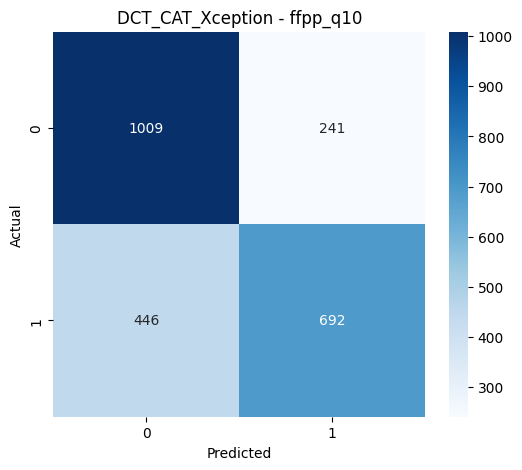


saved: /content/drive/MyDrive/DL_Project/results/dct_cat_xception_compression_results/dct_cat_xception_ffpp_q10_confusion_matrix.pdf


In [46]:
save_confusion_matrix(
    dct_metrics['ffpp_q10'],
    'ffpp_q10',
    'DCT_CAT_Xception'
)

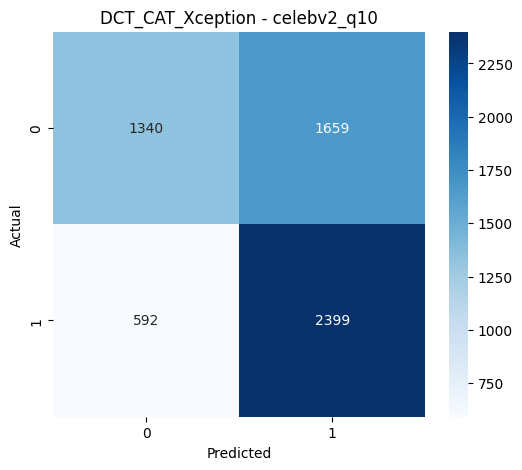


saved: /content/drive/MyDrive/DL_Project/results/dct_cat_xception_compression_results/dct_cat_xception_celebv2_q10_confusion_matrix.pdf


In [47]:
save_confusion_matrix(
    dct_metrics['celebv2_q10'],
    'celebv2_q10',
    'DCT_CAT_Xception'
)

In [48]:
display(dct_results_df[['Dataset', 'Quality', 'AUC']])

,Dataset,Quality,AUC
0,FF++,clean,0.938794
1,FF++,q90,0.933989
2,FF++,q70,0.930857
3,FF++,q50,0.914928
4,FF++,q30,0.887768
5,FF++,q10,0.791187
6,CelebV2,clean,0.792147
7,CelebV2,q90,0.781000
8,CelebV2,q70,0.785238
9,CelebV2,q50,0.774137
